In [1]:
################################################################################
###                                                                          ###
### Created by Haotian XIAO, 2024-2027                                       ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
###                                                                          ###
### And Martin Genet, 2018-2025                                              ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
################################################################################

#################################################################### imports ###

import sys
import dolfin

import myPythonLibrary as mypy
import dolfin_mech as dmech

####################################################################### test ###

def run_linear_homogenization_hollowbox(
    r0_list,
    shape_list=("round", "hex"),
    probe_list=("gx", "gy"),
    perform_tests=0,
):
    import os
    import math
    import dolfin
    import myPythonLibrary as mypy
    import dolfin_mech as dmech

    res_folder = "results_linear_homogenization"
    os.makedirs(res_folder, exist_ok=True)

    test = mypy.Test(
        res_folder=res_folder,
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    mat_params = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1,
        "eta": 1e-5,
    }

    dim = 2
    bcs = "pbc"
    n_steps = 1

    def run_one_probe(shape, r0, probe):
        if probe == "gx":
            gx_ini_lst = [0.0]
            gx_fin_lst = [0.01]
            gy_ini_lst = [0.0]
            gy_fin_lst = [0.0]
        elif probe == "gy":
            gx_ini_lst = [0.0]
            gx_fin_lst = [0.0]
            gy_ini_lst = [0.0]
            gy_fin_lst = [0.01]
        else:
            raise ValueError("probe must be 'gx' or 'gy'")

        res_basename = f"linear-{shape}-r0={r0}-{probe}"

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"]["sigma_bar_" + str(i) + str(j)] = 0.0

        load_params["solid"]["U_bar_00_lst"] = [0.0]
        load_params["solid"]["U_bar_01_lst"] = [0.0]
        load_params["solid"]["U_bar_10_lst"] = [0.0]
        load_params["solid"]["U_bar_11_lst"] = [0.0]

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst
        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        load_params["air"]["pf"] = 0.0
        load_params["air"]["pf_lst"] = [0.0] * n_steps

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3) / 2,
                "xmax": 1.0,
                "ymax": math.sqrt(3) / 2,
                "r0": r0,
                "l": 0.1,
                "hole_shape": shape,
                "add_center_hole": True,
                "mesh_filebasename": res_folder + f"/mesh-{shape}-r0={r0}",
            },
            mat_params={
                "skel": {"parameters": mat_params, "scaling": "no"},
                "bulk": {"parameters": mat_params, "scaling": "no"},
                "pore": {"parameters": mat_params, "scaling": "no"},
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1.0, 0.0),
                        (0.0, 1.0),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs=bcs,
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1e-2],
                "dt_ini_lst": [1e-3],
                "dt_min_lst": [1e-4],
                "dt_max_lst": [5e-3],
            },
            load_params=load_params,
            res_basename=res_folder + "/" + res_basename,
            verbose=0,
        )

        test.test(res_folder + "/" + res_basename)

    for shape in shape_list:
        for r0 in r0_list:
            for probe in probe_list:
                print(f"Running shape={shape}, r0={r0}, probe={probe}")
                run_one_probe(shape=shape, r0=r0, probe=probe)

    return res_folder

In [2]:
r0_list = [0.02, 0.05, 0.072, 0.1, 0.2, 0.315, 0.41]

run_linear_homogenization_hollowbox(
    r0_list=r0_list,
    shape_list=("round", "hex"),
    probe_list=("gx", "gy"),
)

Running shape=round, r0=0.02, probe=gx
Info    : Reconstructing periodicity for curve connection 4 - 8                                                           
Info    : Reconstructing periodicity for curve connection 6 - 2
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Ellipse)
Info    : [ 50%] Meshing curve 5 (Ellipse)
Info    : [ 60%] Meshing curve 6 (Line) as a copy of curve 2
Info    : [ 70%] Meshing curve 7 (Ellipse)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Ellipse)
Info    : [100%] Meshing curve 4 (Line) as a copy of curve 8
Info    : Done meshing 1D (Wall 0.000227375s, CPU 0.000247s)
Info    : Meshing 2D...
Info    : Meshing surface 100 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00723346s, CPU 0.006395s)
Info    : Reconstructing periodicity for curve connection 4 - 8
Info    : Reconstructing periodicity for curve connection 6 - 2
Info

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running shape=round, r0=0.02, probe=gy
Info    : Reconstructing periodicity for curve connection 4 - 8                                                           
Info    : Reconstructing periodicity for curve connection 6 - 2
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Ellipse)
Info    : [ 50%] Meshing curve 5 (Ellipse)
Info    : [ 60%] Meshing curve 6 (Line) as a copy of curve 2
Info    : [ 70%] Meshing curve 7 (Ellipse)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Ellipse)
Info    : [100%] Meshing curve 4 (Line) as a copy of curve 8
Info    : Done meshing 1D (Wall 0.000221916s, CPU 0.000239s)
Info    : Meshing 2D...
Info    : Meshing surface 100 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00638762s, CPU 0.006386s)
Info    : Reconstructing periodicity for curve connection 4 - 8
Info    : Reconstructing periodicity for curve connection 6 - 2
Info

...

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running shape=hex, r0=0.315, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of c

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running shape=hex, r0=0.41, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of cu

'results_linear_homogenization'

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src
Saved: plots/linear_homogenization_K_vs_phi.csv


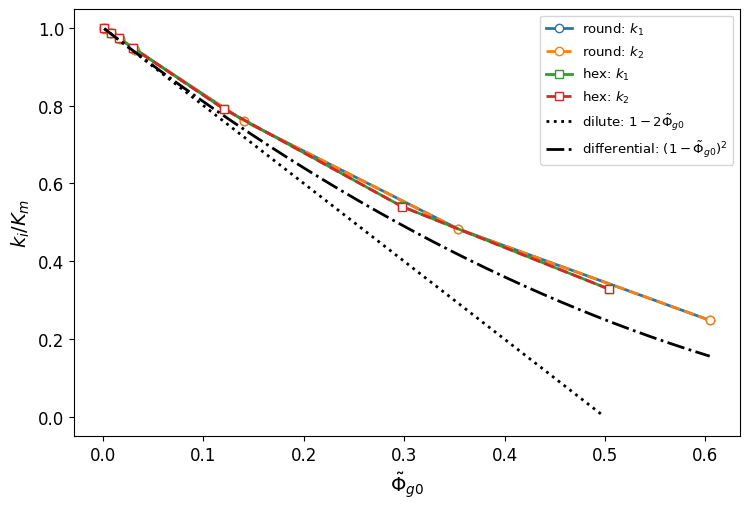

Saved: plots/linear_homogenization_K_vs_phi.png


In [3]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parents[0]
SRC_DIR = PROJECT_DIR / "src"

sys.path.insert(0, str(SRC_DIR))
print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)

from Plot_Microporoflow import plot_linear_homogenization_hollowbox

plot_linear_homogenization_hollowbox(
    res_folder="results_linear_homogenization",
    shape_list=("round", "hex"),
    r0_list=[0.02, 0.05, 0.072, 0.1, 0.2, 0.315, 0.41],
    save_name="plots/linear_homogenization_K_vs_phi.png",
    show_plot=True,
)